In [1]:
from IPython.core.pylabtools import figsize

import data_preprocessor as dp

In [2]:
data = dp.preprocess_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

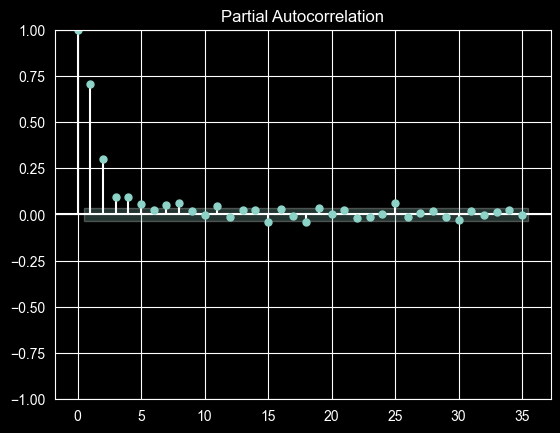

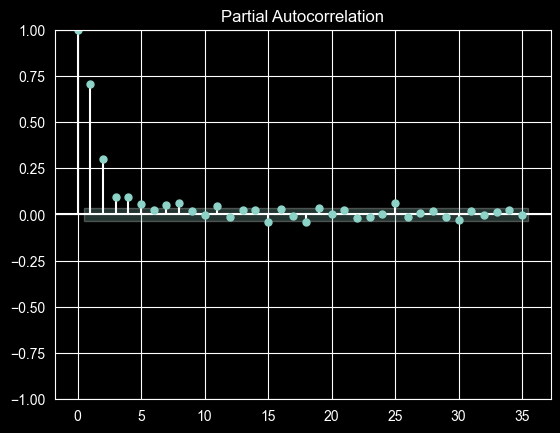

In [38]:
plot_pacf(data['log_return']) # 1 significant lag => p = 1

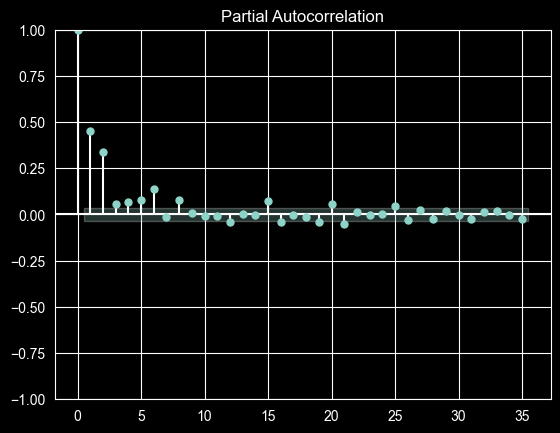

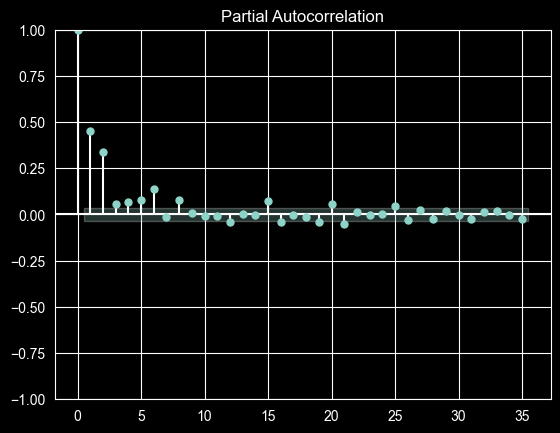

In [6]:
plot_pacf(data['log_return'] ** 2) # 2 significant lags => q = 2

In [39]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data['log_return'], test_size=0.2, shuffle=False)
train *= 100
test *= 100

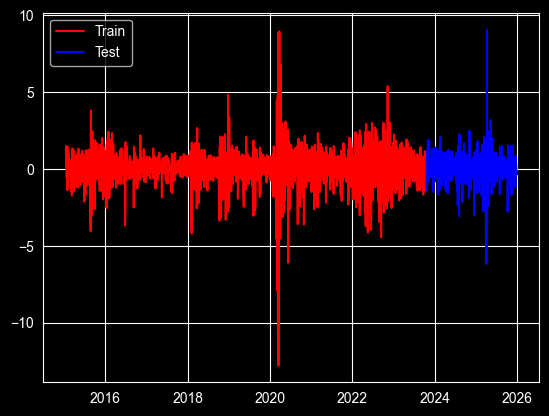

In [40]:
plt.plot(train, color='red', label='Train')
plt.plot(test, color='blue', label='Test')
plt.legend()
plt.show()

In [41]:
import numpy as np
from arch import arch_model
model = arch_model(train, p=1, q=1).fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 23865.23611082395
Iteration:      2,   Func. Count:     17,   Neg. LLF: 12711.799507156915
Iteration:      3,   Func. Count:     26,   Neg. LLF: 4777.41227473128
Iteration:      4,   Func. Count:     33,   Neg. LLF: 2884.8301055532347
Iteration:      5,   Func. Count:     39,   Neg. LLF: 3687.45836039581
Iteration:      6,   Func. Count:     45,   Neg. LLF: 2862.0745918444627
Iteration:      7,   Func. Count:     51,   Neg. LLF: 2861.0216099089607
Iteration:      8,   Func. Count:     56,   Neg. LLF: 2861.021185087914
Iteration:      9,   Func. Count:     61,   Neg. LLF: 2861.021182870062
Iteration:     10,   Func. Count:     65,   Neg. LLF: 2861.0211828698075
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2861.021182870062
            Iterations: 10
            Function evaluations: 65
            Gradient evaluations: 10


In [10]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2861.02
Distribution:                  Normal   AIC:                           5730.04
Method:            Maximum Likelihood   BIC:                           5752.83
                                        No. Observations:                 2204
Date:                Thu, Feb 19 2026   Df Residuals:                     2203
Time:                        00:19:28   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0768  1.599e-02      4.804  1.555e-06 [4.547e-02,  0.108]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0380  1.076e-02      3.527  4.198e-04 [1.687e-02,5.906e-02]
alpha[1]       0.1972  3.385e-02      5.827  5.648e-09     [  0.131,  0.264]
beta[1]        0.7784  3.127e-02     24.895 8.422e-137     [  0.717,  0.840]
============================================================================

Covariance estimator: robust
"""

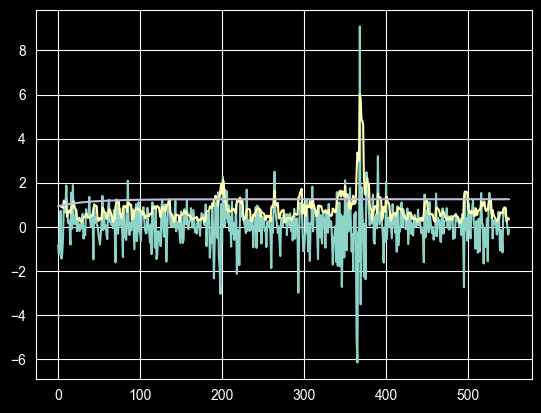

In [11]:
preds = model.forecast(horizon=len(test))
test.reset_index(drop=True, inplace=True)
rolling = test.rolling(window=5).std()

plt.plot(test)
plt.plot(rolling)
plt.plot(np.sqrt(preds.))

In [19]:
train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

model = arch_model(train, p=1, q=1).fit()

train = train.to_list()
test = test.to_list()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 23865.23611082395
Iteration:      2,   Func. Count:     17,   Neg. LLF: 12711.799507156915
Iteration:      3,   Func. Count:     26,   Neg. LLF: 4777.41227473128
Iteration:      4,   Func. Count:     33,   Neg. LLF: 2884.8301055532347
Iteration:      5,   Func. Count:     39,   Neg. LLF: 3687.45836039581
Iteration:      6,   Func. Count:     45,   Neg. LLF: 2862.0745918444627
Iteration:      7,   Func. Count:     51,   Neg. LLF: 2861.0216099089607
Iteration:      8,   Func. Count:     56,   Neg. LLF: 2861.021185087914
Iteration:      9,   Func. Count:     61,   Neg. LLF: 2861.021182870062
Iteration:     10,   Func. Count:     65,   Neg. LLF: 2861.0211828698075
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2861.021182870062
            Iterations: 10
            Function evaluations: 65
            Gradient evaluations: 10


In [22]:
preds = []

last = 0
for item in test:
    pred = model.forecast(horizon=1)
    preds.append(pred.variance.values[-1])

    train.append(item)
    model = arch_model(train, p=1, q=1).fit()

preds

Iteration:      1,   Func. Count:      6,   Neg. LLF: 30181.64856526801
Iteration:      2,   Func. Count:     17,   Neg. LLF: 16003.148773685365
Iteration:      3,   Func. Count:     27,   Neg. LLF: 5773.442340807991
Iteration:      4,   Func. Count:     34,   Neg. LLF: 6043.754128330685
Iteration:      5,   Func. Count:     40,   Neg. LLF: 3918.28616598963
Iteration:      6,   Func. Count:     47,   Neg. LLF: 3558.184487140686
Iteration:      7,   Func. Count:     52,   Neg. LLF: 3558.1781917319704
Iteration:      8,   Func. Count:     57,   Neg. LLF: 3558.175533036424
Iteration:      9,   Func. Count:     62,   Neg. LLF: 3558.1754911646194
Iteration:     10,   Func. Count:     67,   Neg. LLF: 3558.1754902373214
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3558.1754902373214
            Iterations: 10
            Function evaluations: 67
            Gradient evaluations: 10
Iteration:      1,   Func. Count:      6,   Neg. LLF: 30290.9956789

[array([0.37878118]),
 array([0.49232709]),
 array([0.74816234]),
 array([0.64336483]),
 array([0.62290445]),
 array([0.94141002]),
 array([1.0698799]),
 array([0.94243332]),
 array([1.00599449]),
 array([0.89373214]),
 array([0.91245356]),
 array([1.3272841]),
 array([1.22048347]),
 array([1.00877278]),
 array([0.84695668]),
 array([0.71136806]),
 array([0.74344756]),
 array([1.00856164]),
 array([0.84438865]),
 array([1.28442386]),
 array([1.05939591]),
 array([0.88060434]),
 array([0.73890388]),
 array([0.70112232]),
 array([0.6098972]),
 array([0.54168193]),
 array([0.46899253]),
 array([0.42460468]),
 array([0.3757934]),
 array([0.3424109]),
 array([0.32603963]),
 array([0.34273117]),
 array([0.38005138]),
 array([0.34386734]),
 array([0.35136156]),
 array([0.40787265]),
 array([0.38146007]),
 array([0.35854529]),
 array([0.34849387]),
 array([0.60328642]),
 array([0.52284539]),
 array([0.45505777]),
 array([0.42403037]),
 array([0.41984417]),
 array([0.80319203]),
 array([0.83303

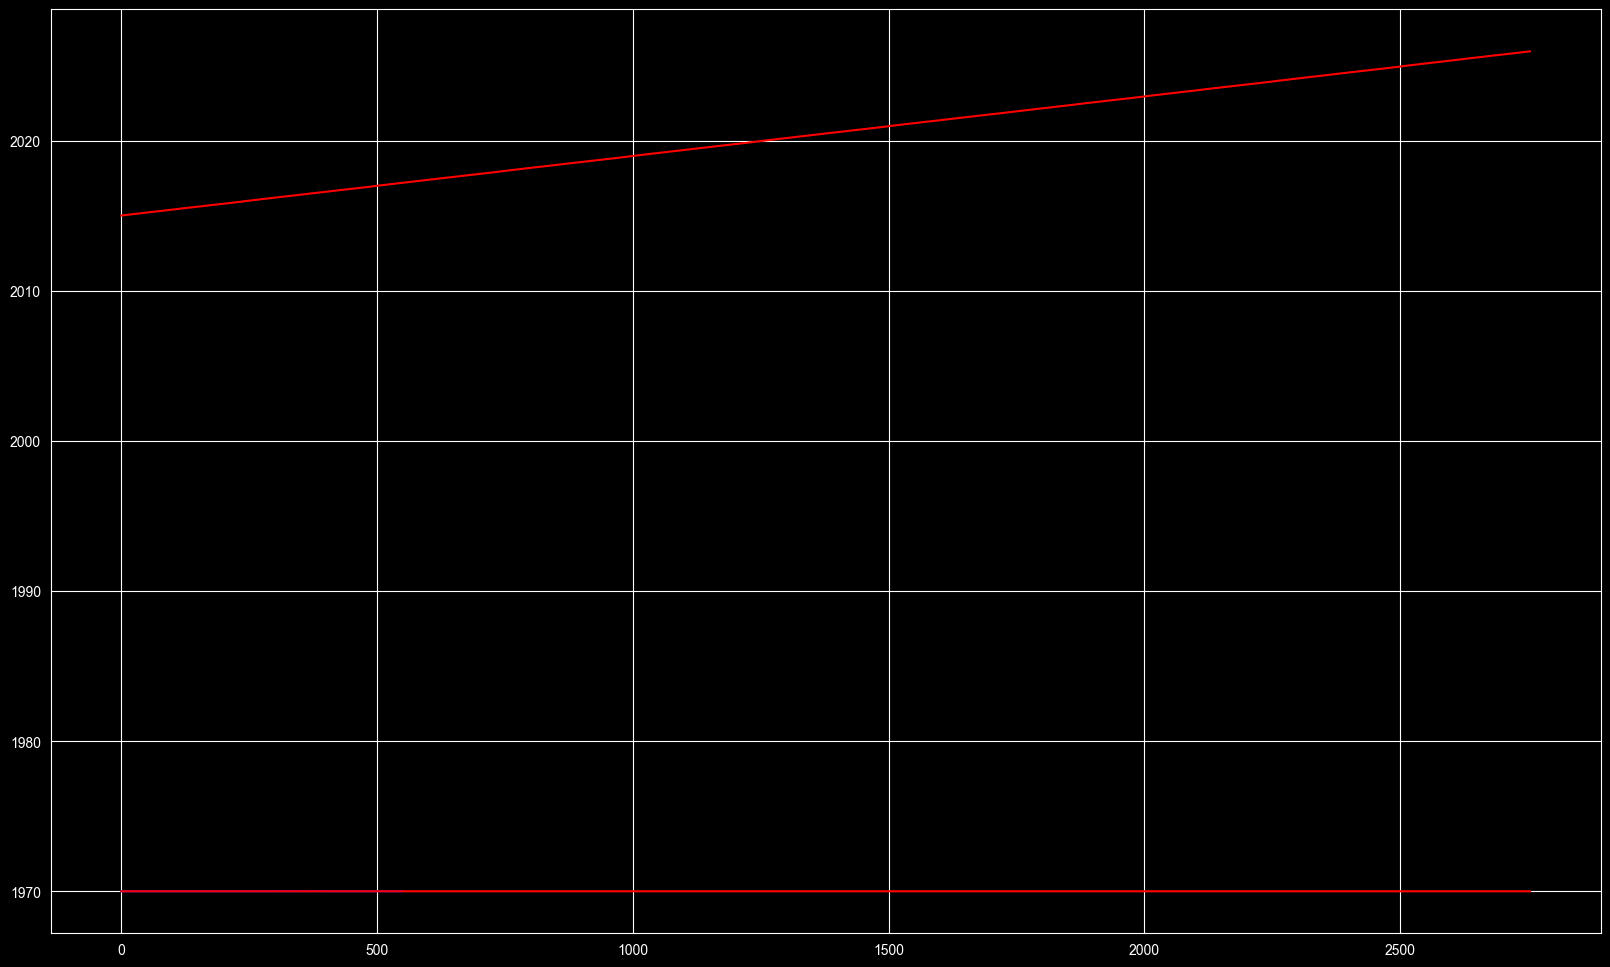

In [43]:
import pandas as pd
rolling = pd.Series(test).rolling(window=5).std()

plt.subplots(figsize=(20,12))
plt.plot(np.sqrt(preds), color='blue')
plt.plot(rolling, color='red')

In [35]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import root_mean_squared_error

mape = mean_absolute_percentage_error(rolling[5:], np.sqrt(preds[5:]))
rmse = root_mean_squared_error(rolling[5:], np.sqrt(preds[5:]))
print(mape)
print(rmse)

0.41403545174162926
0.33356648687311097
